# Библиотеки

In [27]:
from itertools import combinations
from pprint import pprint

import pandas as pd
import numpy as np
from scipy import stats
import pingouin as pg
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split # разбивка на тестовую и обучающую выборку
from sklearn.metrics import classification_report, precision_recall_curve, roc_curve, roc_auc_score # классификационный отчет с метриками качества, а также данные под кривые для визуалок + мера площади под кривой

import seaborn as sns

## 11.3 Бинарная логистическая регрессия

- `Группа` где 0 те кто отказались и 1 те кто подписались  на платную версию сервиса
- `ДоходМес` месячный доход указанный самими пользователями (укажите ориентировочную сумма Вашего месячного дохода)
- `ОценкаИнтернет` самооценка пользователями себя как пользователя Интернет по 10-бальной шкале (Оцените себя как интернет-пользователя, где 1 Полный Чайник, а 10 Мега-Профи) 
- `ВремяПрилож` объективный параметр замера средненедельного времени, который пользователь проводил в приложении

In [6]:
d = pd.read_excel('./data/WebService.xlsx')

In [9]:
d.sample(3)

,Группа,ДоходМес,ОценкаИнтернет,ВремяПрилож
1,0,55.5,4,5
43,1,77.0,5,14
47,0,50.0,6,5


In [11]:
# бинарную зависимую (Группа) и независимые переменные (все остальные)
y = d['Группа']
X = d[['ДоходМес', 'ОценкаИнтернет', 'ВремяПрилож']]
# технический столбец с 1 (константу)
X = sm.add_constant(X)

In [12]:
# обученной логистической регрессии, предсказывающей подписку (1) или отказ от нее (0)
model = sm.Logit(endog=y, exog=X).fit()

Optimization terminated successfully.
         Current function value: 0.102263
         Iterations 10


- `converged` - True (найдено устойчивое решение для коэффициентов модели) или False (много итераций и нет устойчивого решения с оптимальными коэффициентами, блуждание без сходимости данных)
- `Pseudo-R2`  (0.4-0.6 нормально; а если выше - вообще хорошо, но чем ближе к 0.9 надо быть поаккуратнее так как может быть эффект переобучения, выглядящий как модель с крутыми предсказательными способностями)
- `LLR p-value` значимость от нулевой-модели  - если значим, значит наша модель лучше чем модель без предикторов
- Посмотрите на значимость и направление\знак коэффициентов:  переменные\признаки с положительным коэф. увеличивают шанс продления подписки на платной основе, отрицательные - уменьшают.
- чтобы интерпретировать коэффициенты в тех же величинах, что и данные в датафрейме (например, при увеличении оценки интернета на 1 балл шанс попасть в 1 (подписаться) возрастает примерно в 6.5 раз) - то надо вывести из коэффициентов экспоненту: например, ДоходМес надо  exp(0.1637) ≈ 1.18, что значит при увеличении дохода на 1 единицу (в тех же единицах, в которых доход измеряется в данных, т.е., в тыс рублей) шанс попасть в группу 1 (подписка) вырастает на 18%. И кстати, константа  = exp(-26.56) ≈ 3.1e-12 (практически ноль), что как раз и говорит, что если все предикторы равны 0, то вероятность попасть в 1 практически равна 0.

In [14]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 Группа   No. Observations:                   59
Model:                          Logit   Df Residuals:                       55
Method:                           MLE   Df Model:                            3
Date:                Mon, 05 Jan 2026   Pseudo R-squ.:                  0.8522
Time:                        11:37:17   Log-Likelihood:                -6.0335
converged:                       True   LL-Null:                       -40.819
Covariance Type:            nonrobust   LLR p-value:                 5.272e-15
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const            -26.5643     10.715     -2.479      0.013     -47.566      -5.563
ДоходМес           0.1637      0.079      2.083      0.037       0.010       0.318
ОценкаИнтернет     1.8672      0.849      2.200      0.028       0.204       3.531
ВремяПрилож        0.3470      0.168      2.060      0.039       0.017       0.677
==================================================================================

Possibly complete quasi-separation: A fraction 0.10 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

In [19]:
d['y_pred'] = model.predict(X)

In [21]:
d['y_pred'] = (model.predict(X)>=0.5).astype(int)

In [23]:
pd.crosstab(d['Группа'], d['y_pred'])

y_pred,0,1
Группа,,
0,29,2
1,1,27


In [25]:
(d['Группа']== d['y_pred']).mean()

np.float64(0.9491525423728814)

In [26]:
model = smf.logit('Группа ~ ДоходМес + ОценкаИнтернет + ВремяПрилож', data=d).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.102263
         Iterations 10


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                 Группа   No. Observations:                   59
Model:                          Logit   Df Residuals:                       55
Method:                           MLE   Df Model:                            3
Date:                Mon, 05 Jan 2026   Pseudo R-squ.:                  0.8522
Time:                        13:34:08   Log-Likelihood:                -6.0335
converged:                       True   LL-Null:                       -40.819
Covariance Type:            nonrobust   LLR p-value:                 5.272e-15
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        -26.5643     10.715     -2.479      0.013     -47.566      -5.563
ДоходМес           0.1637      0.079      2.083      0.037       0.010       0.318
ОценкаИнтернет     1.8672      0.849      2.200      0.028       0.204       3.531
ВремяПрилож        0.3470      0.168      2.060      0.039       0.017       0.677
==================================================================================

Possibly complete quasi-separation: A fraction 0.10 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

## 11.4 Как понять хороша ли модель: Precision, Recall, ROC-AUC

In [32]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Группа          59 non-null     int64  
 1   ДоходМес        59 non-null     float64
 2   ОценкаИнтернет  59 non-null     int64  
 3   ВремяПрилож     59 non-null     int64  
 4   y_pred          59 non-null     int64  
dtypes: float64(1), int64(4)
memory usage: 2.4 KB


In [42]:
print(f"n: {X_train.shape[0]}, part: {X_train.shape[0] / d.shape[0]:.1%}")
print(f"n: {X_test.shape[0]}, part: {X_test.shape[0] / d.shape[0]:.1%}")

n: 41, part: 69.5%
n: 18, part: 30.5%


In [30]:
X1 = d[['ДоходМес','ОценкаИнтернет','ВремяПрилож']]

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X1, y, test_size=0.3) 

In [43]:
MLR = LogisticRegression().fit(X1, y)

In [44]:
MLR

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [45]:
MLR.coef_

array([[0.13097352, 1.28449552, 0.30250381]])

In [47]:
MLR = LogisticRegression().fit(X_train, y_train)

In [48]:
y_p = MLR.predict(X_test)

- `Precision` (точность) отвечает на вопрос: "если модель говорит 'не подписался' (0) или 'подписался' (1) - насколько ей можно верить?" Или другими словами какой % из тех, кого модель считает 'подписавшимися\неподписавшимися', действительно подписались или не продлили подписку.
- `Recall` (полнота) - отвечает на вопрос: "все ли подписавшиеся/неподписавшиеся найдены?" Или другими словами из всех подписавшихся\неподписавшихся модель правильно нашла только такой-то %
- `F1-score` - баланс между precision и recall
- `Accuracy` - точность модели в целом для сбалансированных групп\классов (когда 0 и 1 одинаковое кол-во - что видно в support для 0 и 1). Если количество не сбалансировано, то смотреть weighted avg  (среднее с учётом размера групп\классов, что важнее в реальных задачах, нежели просто macro avg)

In [49]:
print(
    classification_report(y_test, y_p)
     )

              precision    recall  f1-score   support

           0       0.80      0.89      0.84         9
           1       0.88      0.78      0.82         9

    accuracy                           0.83        18
   macro avg       0.84      0.83      0.83        18
weighted avg       0.84      0.83      0.83        18



In [50]:
y_prob = MLR.predict_proba(X_test)[:, 1]

In [51]:
P, R, T = precision_recall_curve(y_test, y_prob)

<Axes: xlabel='R'>

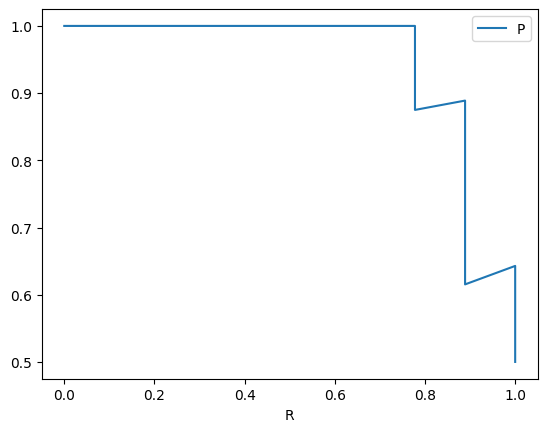

In [52]:
pd.DataFrame({'R':R, 'P':P}).plot(x='R', y='P')

In [53]:
FPR, TPR, T = roc_curve(y_test, y_prob)

<Axes: xlabel='FPR '>

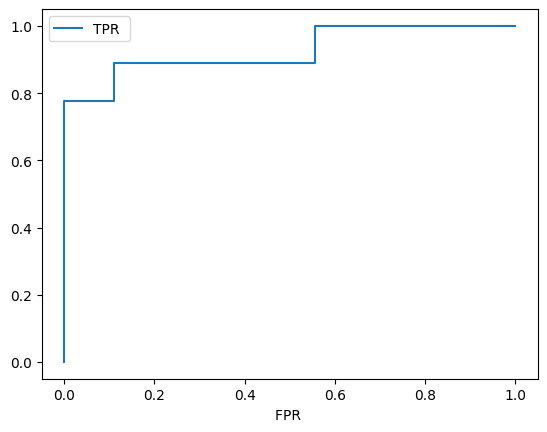

In [54]:
pd.DataFrame({'FPR ':FPR , 'TPR ':TPR }).plot(x='FPR ', y='TPR ')

In [55]:
roc_auc_score(y_test, y_prob)

0.9259259259259258